
=== λ = 0.001 ===
Epoch 1 | Loss 696.08 | Acc 46.89% | Sparsity 92.07%
Epoch 2 | Loss 552.57 | Acc 50.05% | Sparsity 92.10%
Epoch 3 | Loss 503.46 | Acc 52.00% | Sparsity 92.13%
Epoch 4 | Loss 470.15 | Acc 52.46% | Sparsity 92.16%
Epoch 5 | Loss 441.93 | Acc 53.61% | Sparsity 92.18%
Epoch 6 | Loss 417.41 | Acc 53.52% | Sparsity 92.21%
Epoch 7 | Loss 395.30 | Acc 53.39% | Sparsity 92.23%
Epoch 8 | Loss 374.79 | Acc 53.01% | Sparsity 92.25%
Epoch 9 | Loss 354.77 | Acc 53.48% | Sparsity 92.26%
Epoch 10 | Loss 335.30 | Acc 53.16% | Sparsity 92.28%

=== λ = 0.005 ===
Epoch 1 | Loss 705.04 | Acc 47.58% | Sparsity 92.10%
Epoch 2 | Loss 554.81 | Acc 50.20% | Sparsity 92.14%
Epoch 3 | Loss 505.26 | Acc 51.39% | Sparsity 92.17%
Epoch 4 | Loss 471.04 | Acc 53.07% | Sparsity 92.20%
Epoch 5 | Loss 441.95 | Acc 52.71% | Sparsity 92.23%
Epoch 6 | Loss 416.51 | Acc 53.60% | Sparsity 92.25%
Epoch 7 | Loss 394.22 | Acc 53.66% | Sparsity 92.27%
Epoch 8 | Loss 372.44 | Acc 53.60% | Sparsity 92.29%
Epoch 9

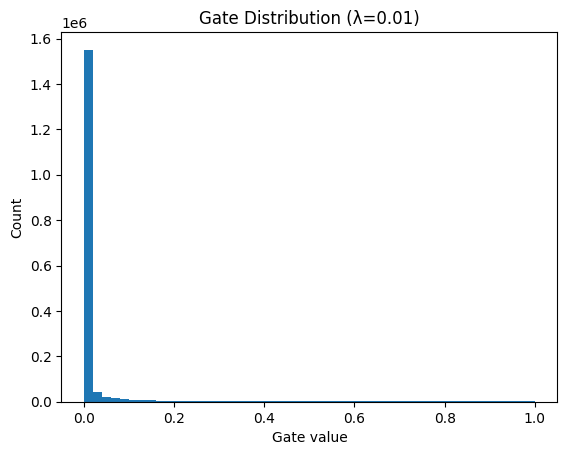

In [2]:
# self_pruning_fixed.py

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Prunable Linear Layer
# -------------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        # 🔥 FIX 1: negative init → easier pruning
        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features) - 2.0
        )

        nn.init.kaiming_uniform_(self.weight, nonlinearity='relu')

    def forward(self, x):
        # 🔥 FIX 2: sharper sigmoid (more binary)
        gates = torch.sigmoid(5 * self.gate_scores)

        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(5 * self.gate_scores).detach()


# -------------------------------
# Model
# -------------------------------
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),

            PrunableLinear(3072, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            PrunableLinear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            PrunableLinear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            PrunableLinear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

    def prunable_layers(self):
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                yield m


# -------------------------------
# Sparsity Loss
# -------------------------------
def sparsity_loss(model):
    loss = 0.0
    count = 0

    for layer in model.prunable_layers():
        gates = torch.sigmoid(5 * layer.gate_scores)
        loss += gates.mean()   # 🔥 FIX 3: normalize
        count += 1

    return loss / count


# -------------------------------
# Evaluation
# -------------------------------
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


# -------------------------------
# Sparsity
# -------------------------------
def compute_sparsity(model, threshold=0.05):  # 🔥 FIX 4
    all_gates = []

    for layer in model.prunable_layers():
        g = layer.get_gates().cpu().numpy().flatten()
        all_gates.extend(g)

    all_gates = np.array(all_gates)
    sparsity = (all_gates < threshold).mean()

    return sparsity * 100, all_gates


# -------------------------------
# Data
# -------------------------------
def get_data():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train = datasets.CIFAR10("./data", train=True, download=True, transform=transform)
    test = datasets.CIFAR10("./data", train=False, download=True, transform=transform)

    train_loader = DataLoader(train, batch_size=128, shuffle=True)
    test_loader = DataLoader(test, batch_size=128)

    return train_loader, test_loader


# -------------------------------
# Training
# -------------------------------
def train_model(lam, train_loader, test_loader, device, epochs=10):
    model = Net().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    ce = nn.CrossEntropyLoss()

    print(f"\n=== λ = {lam} ===")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()

            out = model(x)
            cls_loss = ce(out, y)
            sp_loss = sparsity_loss(model)

            loss = cls_loss + lam * sp_loss

            loss.backward()
            opt.step()

            total_loss += loss.item()

        acc = evaluate(model, test_loader, device)
        sparsity, _ = compute_sparsity(model)

        print(f"Epoch {epoch+1} | Loss {total_loss:.2f} | Acc {acc:.2f}% | Sparsity {sparsity:.2f}%")

    final_acc = evaluate(model, test_loader, device)
    final_sp, gates = compute_sparsity(model)

    return model, final_acc, final_sp, gates


# -------------------------------
# Main
# -------------------------------
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, test_loader = get_data()

    # 🔥 FIX 5: stronger lambdas
    lambdas = [1e-3, 5e-3, 1e-2]

    results = {}
    best_model = None
    best_score = -1

    for lam in lambdas:
        model, acc, sp, gates = train_model(lam, train_loader, test_loader, device)

        results[lam] = (acc, sp)

        score = acc - 0.1 * sp
        if score > best_score:
            best_score = score
            best_model = (model, gates, lam)

    # -------------------------------
    # Results
    # -------------------------------
    print("\nFinal Results:")
    print("Lambda | Accuracy | Sparsity")

    for lam, (acc, sp) in results.items():
        print(f"{lam} | {acc:.2f}% | {sp:.2f}%")

    # -------------------------------
    # Plot
    # -------------------------------
    _, gates, lam = best_model

    plt.hist(gates, bins=50)
    plt.title(f"Gate Distribution (λ={lam})")
    plt.xlabel("Gate value")
    plt.ylabel("Count")
    plt.show()


if __name__ == "__main__":
    main()